# Stage 0 — Frozen DINOv2 Embedding QC

Thin notebook: it only **imports**, **calls** `src/`, and **displays**. All
Excel/label logic lives in `src/data.py`; all model/embedding logic in
`src/embeddings.py`. Output: `outputs/analysis/qc_embedding_report.csv`.

Fill in the `EDIT-ME` paths in `config.yaml` before running.

In [1]:
import sys
from pathlib import Path

# Locate the folder root (the dir containing config.yaml) and make src importable.
ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config
from src import data, embeddings

cfg = load_config()
print('model   :', cfg['analysis']['model'])
print('layers  :', cfg['analysis']['layers'])
print('pooling :', cfg['analysis']['pooling'])
print('device  :', cfg['analysis']['device'])
print('output  :', cfg['paths']['output_dir'])

model   : facebook/dinov2-large
layers  : [18, 22, 24]
pooling : ['cls', 'mean_patch']
device  : cuda:1
output  : /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis


In [2]:
# Discover figures (prints the parse preview for you to confirm).
figures = data.list_figures(cfg)
figures.head()

[list_figures] scanned: /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1627_DS/Shrouded vs Openrotor/Images Processed
[list_figures] found 72 figures across 72 distinct patent_ids

[list_figures] CONFIRM the parse convention (showing first 12):
                                   figure_id        patent_id shrouded_open        cpc figure_type
     CA2963502A1_OPN_B64C290025_p001_c01.png      CA2963502A1           OPN B64C290025    p001_c01
    CN108657426A_OPN_B64C290033_p007_c04.png     CN108657426A           OPN B64C290033    p007_c04
DE102019102189A1_OPN_B64C290033_p014_c07.png DE102019102189A1           OPN B64C290033    p014_c07
     EP2570345A1_OPN_B64C290033_p009_c05.png      EP2570345A1           OPN B64C290033    p009_c05
       FR3096959A1_OPN_B64U5014_p012_c03.png      FR3096959A1           OPN   B64U5014    p012_c03
   GB202306162D0_OPN_B64C290033_p001_c01.png    GB202306162D0           OPN B64C290033    p001_c01
    US12600459B1_OPN_B64C

,figure_id,patent_id,shrouded_open,cpc,figure_type,path
0,CA2963502A1_OPN_B64C290025_p001_c01.png,CA2963502A1,OPN,B64C290025,p001_c01,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
1,CN108657426A_OPN_B64C290033_p007_c04.png,CN108657426A,OPN,B64C290033,p007_c04,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
2,DE102019102189A1_OPN_B64C290033_p014_c07.png,DE102019102189A1,OPN,B64C290033,p014_c07,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
3,EP2570345A1_OPN_B64C290033_p009_c05.png,EP2570345A1,OPN,B64C290033,p009_c05,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
4,FR3096959A1_OPN_B64U5014_p012_c03.png,FR3096959A1,OPN,B64U5014,p012_c03,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...


In [3]:
# Optional: label coverage sanity check (skipped cleanly if labels not yet configured).
try:
    labels = data.load_labels(cfg)
    have = figures['patent_id'].isin(labels.index)
    print(f'labelled patents in sheet : {len(labels)}')
    print(f'figures whose patent_id is in the sheet : {int(have.sum())} / {len(figures)}')
except Exception as e:
    print('label load skipped:', type(e).__name__, '-', e)

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


labelled patents in sheet : 1639
figures whose patent_id is in the sheet : 72 / 72


In [4]:
# Compute embeddings (or reload if already on disk).
emb_dir = Path(cfg['paths']['output_dir']) / 'embeddings'
if (emb_dir / 'metadata.parquet').exists():
    print('reloading existing embeddings from', emb_dir)
    result = embeddings.load_embeddings(cfg)
else:
    result = embeddings.compute_embeddings(figures, cfg)
    embeddings.save_embeddings(result, cfg)

print('arrays:', sorted(result['arrays'].keys()))

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

[load_model] detected architecture:
                model_name: facebook/dinov2-large
                   variant: base
         num_hidden_layers: 24
                hidden_dim: 1024
       num_register_tokens: 0
                  n_prefix: 1
                    device: cuda:1
    hidden_states length per forward = 25 (index 0 = embeddings, index i = block i output)



embedding: 100%|██████████| 3/3 [00:01<00:00,  2.34batch/s]

[save_embeddings] wrote 6 arrays + metadata to /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis/embeddings
arrays: [(18, 'cls'), (18, 'mean_patch'), (22, 'cls'), (22, 'mean_patch'), (24, 'cls'), (24, 'mean_patch')]


In [5]:
# Build + persist the Stage-0 QC report.
report = embeddings.qc_report(result, seed=cfg['analysis']['seed'])

csv_path = Path(cfg['paths']['output_dir']) / 'qc_embedding_report.csv'
csv_path.parent.mkdir(parents=True, exist_ok=True)
report.to_csv(csv_path, index=False)
print('wrote', csv_path)
report

wrote /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis/qc_embedding_report.csv


,layer,pooling,variant,n_layers,hidden_dim,num_register_tokens,n_prefix,emb_dim,n_figures,n_patents,...,exact_duplicate_count,dim_var_mean,dim_var_min,dim_var_max,near_dead_dims,cos_mean,cos_std,cos_p05,cos_p50,cos_p95
0,18,cls,base,24,1024,0,1,1024,72,72,...,0,0.000039,0.000004,0.000604,0,0.959073,0.017708,0.925262,0.963044,0.980390
1,18,mean_patch,base,24,1024,0,1,1024,72,72,...,0,0.000139,0.000018,0.002026,0,0.855390,0.051521,0.759694,0.862607,0.926553
2,22,cls,base,24,1024,0,1,1024,72,72,...,0,0.000115,0.000003,0.002065,0,0.880648,0.040060,0.793959,0.888786,0.926231
3,22,mean_patch,base,24,1024,0,1,1024,72,72,...,0,0.000132,0.000010,0.001549,0,0.862874,0.043488,0.785486,0.868194,0.922203
4,24,cls,base,24,1024,0,1,1024,72,72,...,0,0.000526,0.000006,0.004595,0,0.453568,0.103478,0.282646,0.453852,0.619084
5,24,mean_patch,base,24,1024,0,1,1024,72,72,...,0,0.000169,0.000003,0.002162,0,0.824083,0.052241,0.729041,0.829559,0.897739


## Visual inspection only — not a metric

The two histograms below are for eyeballing distribution shape only. They are
**not** Stage-0 pass/fail criteria — the numeric gate is in the report table.

visualizing layer/pooling: (18, 'cls') shape (72, 1024)


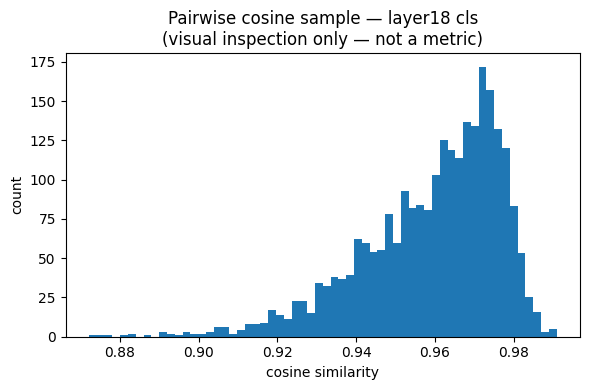

In [6]:
# Pick a representative (layer, pooling) to visualize.
key = sorted(result['arrays'].keys())[0]
arr = result['arrays'][key]
print('visualizing layer/pooling:', key, 'shape', arr.shape)

sims = embeddings._pairwise_cosine_sample(arr, embeddings.PAIRWISE_SAMPLE_SIZE, cfg['analysis']['seed'])
plt.figure(figsize=(6, 4))
plt.hist(sims, bins=60)
plt.title(f'Pairwise cosine sample — layer{key[0]} {key[1]}\n(visual inspection only — not a metric)')
plt.xlabel('cosine similarity'); plt.ylabel('count')
plt.tight_layout(); plt.show()

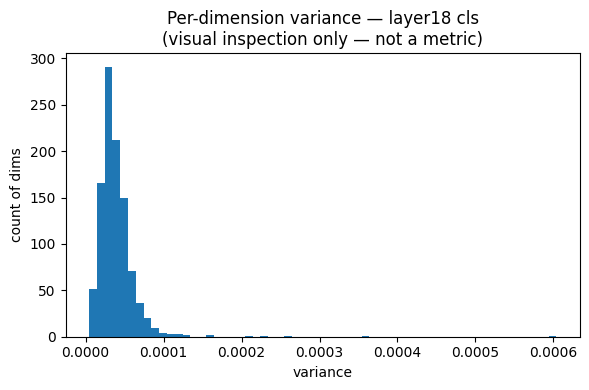

In [7]:
dim_var = arr.var(axis=0)
plt.figure(figsize=(6, 4))
plt.hist(dim_var, bins=60)
plt.title(f'Per-dimension variance — layer{key[0]} {key[1]}\n(visual inspection only — not a metric)')
plt.xlabel('variance'); plt.ylabel('count of dims')
plt.tight_layout(); plt.show()

In [8]:
# Stage-0 gate.
passed = embeddings.qc_pass_fail(report)
print('=' * 48)
print('STAGE 0:', 'PASS ✅' if passed else 'FAIL ❌')
print('=' * 48)
if not passed:
    bad = report[(report['nan_count'] > 0) | (report['inf_count'] > 0) | (report['all_zero_count'] > 0)]
    print('offending (layer, pooling) rows:')
    display(bad[['layer', 'pooling', 'nan_count', 'inf_count', 'all_zero_count']])

STAGE 0: PASS ✅
